# BEAD Random Forest — Separate Models by Technology Type

**Reviewer comment #25**: Technology type is not truly an independent variable — states assign
locations to fiber first, then fixed wireless, then LEO for locations deemed too expensive.
Separate models per technology may perform better by letting each subset have its own
feature relationships.

**Mixed-technology projects**: projects where ≥ 95% of locations share the dominant technology
→ assigned to that technology. Below 95% → 'Mixed' and omitted if small.

**Fiber gets a richer feature set** to address its lower fit:
- `pct_aerial` — aerial vs buried split (single biggest cost driver)
- `topography_z_wmean`, `RRS_wmean` — terrain and road ruggedness
- `rucc_code_wmean` — rurality
- `poverty_rate_wmean` — remoteness proxy

Non-fiber subsets use the base 5 features (technology omitted — constant by construction).

In [10]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PURITY_THRESHOLD = 0.95
TECH_LABELS = {0: 'Unspecified', 40: 'Cable/HFC', 50: 'Fiber', 61: 'Satellite/LEO', 71: 'Fixed Wireless'}

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [11]:
# ── BigQuery data loads ────────────────────────────────────────────────────────
df_projects = client.query("""
SELECT project_id, state, bead_support,
       estimated_miles_aerial_fiber, estimated_miles_buried_fiber
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

# Dominant technology + purity fraction per project
df_locations = client.query("""
SELECT
    project_id,
    COUNT(*) AS funded_locations,
    SAFE_CAST(
        APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value
    AS FLOAT64) AS technology,
    APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].count
        / COUNT(*) AS tech_purity
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

# Location → county mapping via FCC NBM block GEOIDs
# Aggregated to (project_id, county_id) level with location counts
df_loc_county = client.query("""
SELECT
    loc.project_id,
    SUBSTR(nbm.block_geoid, 1, 5) AS county_id,
    COUNT(*) AS location_count
FROM `broadband-data.fp_approved.locations` loc
JOIN `broadband-data.fcc_bdc.nbm_hive` nbm
  ON loc.location_id = nbm.location_id
WHERE nbm.period = '2025_06'
GROUP BY loc.project_id, county_id
""").to_dataframe()

# CAI count per project
df_cai = client.query("""
SELECT project_id, COUNT(*) AS cai_count
FROM `broadband-data.fp_approved.loc_cai`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_nbm_state = client.query("""
SELECT state, COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_bdc.nbm_hive` GROUP BY state
""").to_dataframe()
df_nbm_state['state'] = df_nbm_state['state'].map(state_name_to_abbr)
df_nbm_state = df_nbm_state.dropna(subset=['state'])

df_state_pop = client.query("""
SELECT stateabbr AS state, SUM(pop2020) AS state_population
FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr
""").to_dataframe()

print(f'Projects:       {df_projects.shape[0]}')
print(f'Loc aggregates: {df_locations.shape[0]}')
print(f'Loc-county rows:{df_loc_county.shape[0]}')
print(f'CAI projects:   {df_cai.shape[0]}')

Projects:       5740
Loc aggregates: 5715
Loc-county rows:12098
CAI projects:   5744


In [12]:
# ── Local county-level files (same sources as bead_rf_revised.ipynb) ───────────

# RUCC 2023 — Rural-Urban Continuum Codes (long → wide format)
df_rucc_raw = pd.read_csv("../Ruralurbancontinuumcodes2023.csv", encoding="ISO-8859-1")
df_rucc_wide = df_rucc_raw.pivot_table(
    index=["FIPS", "State", "County_Name"], columns="Attribute",
    values="Value", aggfunc="first"
).reset_index()
df_rucc_wide.columns.name = None
df_rucc_wide["county_id"] = df_rucc_wide["FIPS"].astype(str).str.zfill(5)
df_rucc_wide["RUCC_2023"] = pd.to_numeric(df_rucc_wide["RUCC_2023"], errors="coerce")
df_rucc = df_rucc_wide[["county_id", "RUCC_2023"]].rename(columns={"RUCC_2023": "rucc_code"})
print(f"RUCC counties: {df_rucc.shape[0]}")

# Natural Amenities Scale — topography_z (USDA ERS, 1999)
df_topo_raw = pd.read_excel("../natamenf.xls")
df_topo_raw = df_topo_raw.iloc[103:]
df_topo_raw.columns = df_topo_raw.iloc[0]
df_topo_raw = df_topo_raw[1:].reset_index(drop=True)
df_topo_raw["county_id"] = df_topo_raw["FIPS Code"].astype(str).str.zfill(5)
df_topo_raw = df_topo_raw.rename(columns={"TOPOG - Z": "topography_z", "Water area * 100": "water_area_pct"})
df_topo = df_topo_raw[["county_id", "topography_z", "water_area_pct"]].copy()
df_topo["topography_z"] = pd.to_numeric(df_topo["topography_z"], errors="coerce")
print(f"Topo counties:  {df_topo.shape[0]}")

# Area and Road Ruggedness Scales (USDA ERS, 2020 tracts → county mean)
df_rugged_raw = pd.read_csv("../ruggedness-scales-2020-tracts.csv", encoding="ISO-8859-1")
df_rugged_raw["county_id"] = df_rugged_raw["CountyFIPS23"].astype(str).str.zfill(5)
df_rugged = df_rugged_raw.groupby("county_id")[["RRS", "ARS"]].mean().reset_index()
print(f"Ruggedness counties: {df_rugged.shape[0]}")

# ACS 5-Year poverty estimates (county level)
df_pov_raw = pd.read_csv(
    "../ACSDT5Y2024.B17001_2026-07-15T133739/ACSDT5Y2024.B17001-Data.csv"
).iloc[1:]  # skip metadata row
df_pov_raw["county_id"] = df_pov_raw["GEO_ID"].str[-5:]
df_pov_raw["B17001_001E"] = pd.to_numeric(df_pov_raw["B17001_001E"], errors="coerce")
df_pov_raw["B17001_002E"] = pd.to_numeric(df_pov_raw["B17001_002E"], errors="coerce")
df_pov_raw["poverty_rate"] = df_pov_raw["B17001_002E"] / df_pov_raw["B17001_001E"].replace(0, np.nan)
df_poverty = df_pov_raw[["county_id", "poverty_rate"]].dropna()
print(f"Poverty counties: {df_poverty.shape[0]}")

# Combine into single county feature table
df_county = (
    df_rucc
    .merge(df_topo,    on="county_id", how="outer")
    .merge(df_rugged,  on="county_id", how="outer")
    .merge(df_poverty, on="county_id", how="outer")
)
print(f"County feature table: {df_county.shape}")
print(df_county.isna().sum())

RUCC counties: 3235
Topo counties:  3111
Ruggedness counties: 3144
Poverty counties: 3222
County feature table: (3249, 7)
county_id           0
rucc_code          16
topography_z      138
water_area_pct    138
RRS               105
ARS               105
poverty_rate       27
dtype: int64


In [13]:
# ── Project-level geographic features (location-count weighted means) ──────────
GEO_COLS = ['rucc_code', 'topography_z', 'RRS', 'poverty_rate']

df_loc_county = df_loc_county.merge(df_county[['county_id'] + GEO_COLS], on='county_id', how='left')

# Weighted mean: sum(feature * location_count) / sum(location_count)
for col in GEO_COLS:
    df_loc_county[f'{col}_x_count'] = df_loc_county[col].fillna(df_loc_county[col].median()) * df_loc_county['location_count']

proj_geo = df_loc_county.groupby('project_id').agg(
    geo_total_locs = ('location_count', 'sum'),
    n_counties     = ('county_id', 'nunique'),
    **{f'{c}_x_count': (f'{c}_x_count', 'sum') for c in GEO_COLS}
).reset_index()

for col in GEO_COLS:
    proj_geo[f'{col}_wmean'] = proj_geo[f'{col}_x_count'] / proj_geo['geo_total_locs']
    proj_geo = proj_geo.drop(columns=[f'{col}_x_count'])

print(f'Project-level geo features: {proj_geo.shape}')
print(proj_geo[[f"{c}_wmean" for c in GEO_COLS]].describe().round(3))

Project-level geo features: (5665, 7)
       rucc_code_wmean  topography_z_wmean  RRS_wmean  poverty_rate_wmean
count           5665.0              5665.0     5665.0              5665.0
mean             4.273               0.219      1.628               0.133
std               2.62               1.076      0.813               0.048
min                1.0              -1.195        1.0               0.038
25%                2.0               -0.74        1.0               0.099
50%                4.0                0.17       1.25               0.125
75%              6.121                1.08        2.0               0.158
max                9.0               1.839        5.0               0.411


In [14]:
# ── Merge all sources + feature engineering ────────────────────────────────────
df = df_projects.merge(df_locations,   on='project_id', how='left')
df = df.merge(df_nbm_state,            on='state',      how='left')
df = df.merge(df_state_pop,            on='state',      how='left')
df = df.merge(df_cai,                  on='project_id', how='left')
df = df.merge(proj_geo,                on='project_id', how='left')

# Defaults
df['funded_locations']    = df['funded_locations'].fillna(0)
df['technology']          = df['technology'].fillna(0)
df['tech_purity']         = df['tech_purity'].fillna(1.0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population']    = df['state_population'].fillna(0)
df['cai_count']           = df['cai_count'].fillna(0)

# Derived features
aerial = df['estimated_miles_aerial_fiber'].fillna(0)
buried = df['estimated_miles_buried_fiber'].fillna(0)
df['total_fiber_miles']  = aerial + buried
df['pct_aerial']         = (aerial / df['total_fiber_miles'].replace(0, np.nan)).fillna(0)
df['miles_per_location'] = (df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)).fillna(0)
df['pct_cai']            = (df['cai_count'] / df['funded_locations'].replace(0, np.nan)).fillna(0)

# Fill geo wmean NaNs with column medians
for col in [f'{c}_wmean' for c in ['rucc_code', 'topography_z', 'RRS', 'poverty_rate']]:
    df[col] = df[col].fillna(df[col].median())

# Target: funding per location, log-transformed, 2.5–97.5% winsorized
df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
low, high = df['funding_per_location'].quantile([0.025, 0.975])
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]
df['log_funding'] = np.log1p(df['funding_per_location'])

# Technology group
df['tech_name']  = df['technology'].map(TECH_LABELS).fillna('Other')
df['tech_group'] = df.apply(
    lambda r: r['tech_name'] if r['tech_purity'] >= PURITY_THRESHOLD else 'Mixed', axis=1
)

print(f'Samples after filtering: {df.shape[0]}')
print(f'\nTechnology group counts (purity ≥ {PURITY_THRESHOLD:.0%}):')
print(df['tech_group'].value_counts().to_string())

Samples after filtering: 5429

Technology group counts (purity ≥ 95%):
tech_group
Fiber             2569
Satellite/LEO     1996
Fixed Wireless     410
Mixed              244
Other              164
Cable/HFC           43
Unspecified          3


In [15]:
# ── Mixed-technology projects ──────────────────────────────────────────────────
df_mixed = df[df['tech_group'] == 'Mixed'].copy()
mixed_frac = len(df_mixed) / len(df)
print(f'Mixed-technology projects: {len(df_mixed)}  ({mixed_frac:.1%} of total)')

if len(df_mixed) > 0:
    print('\nDominant tech of mixed projects:')
    print(df_mixed['tech_name'].value_counts().to_string())
    print('\nPurity distribution:')
    print(df_mixed['tech_purity'].describe().round(3).to_string())

print(f'\nDecision: {"omit — small fraction" if mixed_frac < 0.05 else "substantial — inspect further"}')

df_pure = df[df['tech_group'] != 'Mixed'].copy()
print(f'Pure-tech projects retained: {len(df_pure)}')

Mixed-technology projects: 244  (4.5% of total)

Dominant tech of mixed projects:
tech_name
Fiber             116
Fixed Wireless     73
Other              30
Cable/HFC          25

Purity distribution:
count    244.000
mean       0.740
std        0.129
min        0.500
25%        0.631
50%        0.746
75%        0.849
max        0.950

Decision: omit — small fraction
Pure-tech projects retained: 5185


In [16]:
# ── State-level fiber statistics (reviewer #25) ────────────────────────────────
df_fiber = df_pure[df_pure['tech_group'] == 'Fiber'].copy()

state_fiber = df_fiber.groupby('state').agg(
    fiber_projects        = ('project_id', 'count'),
    total_fiber_miles_sum = ('total_fiber_miles', 'sum'),
    max_fiber_miles       = ('total_fiber_miles', 'max'),
    total_fiber_locations = ('funded_locations', 'sum'),
    mean_miles_per_loc    = ('miles_per_location', 'mean'),
    max_miles_per_loc     = ('miles_per_location', 'max'),
    pct_aerial_mean       = ('pct_aerial', 'mean'),
).round(3)
state_fiber['state_miles_per_loc'] = (
    state_fiber['total_fiber_miles_sum'] / state_fiber['total_fiber_locations']
).round(3)

print('State-level fiber statistics (sorted by total fiber miles):')
print(state_fiber.sort_values('total_fiber_miles_sum', ascending=False).to_string())

State-level fiber statistics (sorted by total fiber miles):
       fiber_projects  total_fiber_miles_sum  max_fiber_miles  total_fiber_locations  mean_miles_per_loc  max_miles_per_loc  pct_aerial_mean  state_miles_per_loc
state                                                                                                                                                            
WI                 93              47314.000         3678.000                 130723               0.414              1.364            0.130                0.362
MI                109              30881.000         2726.000                 167150               0.235               2.75            0.190                0.185
OR                101              26010.000        19673.000                  50601               7.951             786.92            0.660                0.514
IL                205              21743.350         1054.700                 106214               0.215                1.0       

## Separate RF Models per Technology

**Base features** (all subsets, technology omitted — constant by construction):
`miles_per_location`, `total_fiber_miles`, `state_population`, `state_num_providers`, `pct_cai`

**Fiber-specific features** (base + geographic terrain/rurality):
`pct_aerial`, `topography_z_wmean`, `RRS_wmean`, `rucc_code_wmean`, `poverty_rate_wmean`

Reasoning: fiber construction cost depends heavily on terrain and whether the cable goes aerial
vs buried — neither of which is relevant for satellite or fixed-wireless equipment costs.

In [17]:
BASE_FEATURES = [
    'miles_per_location',
    'total_fiber_miles',
    'state_population',
    'state_num_providers',
    'pct_cai',
]
FIBER_FEATURES = BASE_FEATURES + [
    'pct_aerial',           # aerial vs buried — biggest unit-cost driver
    'topography_z_wmean',   # terrain ruggedness (natural amenities scale)
    'RRS_wmean',            # road ruggedness (USDA ERS)
    'rucc_code_wmean',      # rural-urban continuum (1=urban … 9=very rural)
    'poverty_rate_wmean',   # county poverty rate (proxy for remoteness)
]

TECH_FEATURES = {
    'Fiber':          FIBER_FEATURES,
    'Satellite/LEO':  BASE_FEATURES,
    'Fixed Wireless': BASE_FEATURES,
    'Cable/HFC':      BASE_FEATURES,
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
MIN_N = 50

results = {}
models  = {}
tech_order = ['Fiber', 'Satellite/LEO', 'Fixed Wireless', 'Cable/HFC']

for tech in tech_order:
    subset   = df_pure[df_pure['tech_group'] == tech].copy()
    feat_cols = TECH_FEATURES[tech]
    n = len(subset)

    if n < MIN_N:
        print(f'{tech}: only {n} projects — skipping (< {MIN_N})')
        results[tech] = {'n': n, 'skipped': True}
        continue

    X = subset[feat_cols].fillna(0)
    y = subset['log_funding']

    if n >= 100:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
        rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        y_pred   = rf.predict(X_te)
        r2_test  = r2_score(y_te, y_pred)
        rmse     = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred)))
        mae      = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred))
    else:
        rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        y_pred   = rf.predict(X)
        r2_test  = r2_score(y, y_pred)
        rmse     = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(y_pred)))
        mae      = mean_absolute_error(np.expm1(y), np.expm1(y_pred))
        X_te, y_te = X, y

    n_splits = max(2, min(5, n // 10))
    kf_sub   = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_r2    = cross_val_score(rf, X, y, cv=kf_sub, scoring='r2')

    results[tech] = {
        'n': n, 'skipped': False, 'features': feat_cols,
        'r2_test': r2_test, 'cv_mean': cv_r2.mean(), 'cv_std': cv_r2.std(),
        'rmse': rmse, 'mae': mae,
        'importances': pd.Series(rf.feature_importances_, index=feat_cols),
        'X_te': X_te, 'y_te': y_te, 'y_pred': y_pred,
    }
    models[tech] = rf

    flag = ' [train R² — n < 100]' if n < 100 else ''
    print(f'=== {tech} (n={n}, {len(feat_cols)} features) ===')
    print(f'  Features: {feat_cols}')
    print(f'  Test R²  (log): {r2_test:.4f}{flag}')
    print(f'  CV R²   (log): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
    print(f'  RMSE  (real $): ${rmse:,.0f}')
    print(f'  MAE   (real $): ${mae:,.0f}\n')

=== Fiber (n=2569, 10 features) ===
  Features: ['miles_per_location', 'total_fiber_miles', 'state_population', 'state_num_providers', 'pct_cai', 'pct_aerial', 'topography_z_wmean', 'RRS_wmean', 'rucc_code_wmean', 'poverty_rate_wmean']
  Test R²  (log): 0.4638
  CV R²   (log): 0.4666 ± 0.0241
  RMSE  (real $): $3,516
  MAE   (real $): $2,372

=== Satellite/LEO (n=1996, 5 features) ===
  Features: ['miles_per_location', 'total_fiber_miles', 'state_population', 'state_num_providers', 'pct_cai']
  Test R²  (log): 0.8952
  CV R²   (log): 0.8760 ± 0.0157
  RMSE  (real $): $864
  MAE   (real $): $328

=== Fixed Wireless (n=410, 5 features) ===
  Features: ['miles_per_location', 'total_fiber_miles', 'state_population', 'state_num_providers', 'pct_cai']
  Test R²  (log): 0.3479
  CV R²   (log): 0.3038 ± 0.1395
  RMSE  (real $): $3,947
  MAE   (real $): $1,910

Cable/HFC: only 43 projects — skipping (< 50)


In [18]:
# ── Summary comparison table ───────────────────────────────────────────────────
rows = []
for tech in tech_order:
    r = results.get(tech, {})
    if r.get('skipped'):
        rows.append({'Technology': tech, 'N': r['n'], 'Features': '—',
                     'Test R²': 'skipped', 'CV R²': '', 'RMSE': '', 'MAE': ''})
    elif r:
        rows.append({
            'Technology': tech, 'N': r['n'], 'Features': len(r['features']),
            'Test R²': f"{r['r2_test']:.4f}",
            'CV R²':   f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
            'RMSE':    f"${r['rmse']:,.0f}",
            'MAE':     f"${r['mae']:,.0f}",
        })

print(pd.DataFrame(rows).set_index('Technology').to_string())

                   N Features  Test R²            CV R²    RMSE     MAE
Technology                                                             
Fiber           2569       10   0.4638  0.4666 ± 0.0241  $3,516  $2,372
Satellite/LEO   1996        5   0.8952  0.8760 ± 0.0157    $864    $328
Fixed Wireless   410        5   0.3479  0.3038 ± 0.1395  $3,947  $1,910
Cable/HFC         43        —  skipped                                 


In [19]:
# ── Fiber model: ablation to see each new feature's contribution ───────────────
# Compare base-only vs full fiber feature set
subset_fiber = df_pure[df_pure['tech_group'] == 'Fiber'].copy()
y_fiber = subset_fiber['log_funding']

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
ablation_results = []

# Base features only
X_base = subset_fiber[BASE_FEATURES].fillna(0)
cv_base = cross_val_score(
    RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
    X_base, y_fiber, cv=kf5, scoring='r2'
)
ablation_results.append({'Feature set': 'Base (5 features)', 'CV R²': cv_base.mean(), 'CV std': cv_base.std()})
print(f'Base only:  CV R² = {cv_base.mean():.4f} ± {cv_base.std():.4f}')

# Add one feature at a time
new_feats = [f for f in FIBER_FEATURES if f not in BASE_FEATURES]
running_feats = BASE_FEATURES.copy()
for feat in new_feats:
    running_feats = running_feats + [feat]
    X_run = subset_fiber[running_feats].fillna(0)
    cv_run = cross_val_score(
        RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
        X_run, y_fiber, cv=kf5, scoring='r2'
    )
    delta = cv_run.mean() - ablation_results[-1]['CV R²']
    ablation_results.append({'Feature set': f'+ {feat}', 'CV R²': cv_run.mean(), 'CV std': cv_run.std()})
    print(f'+ {feat:25s}: CV R² = {cv_run.mean():.4f} ± {cv_run.std():.4f}  (Δ = {delta:+.4f})')

abl_df = pd.DataFrame(ablation_results).set_index('Feature set')
print('\n', abl_df.round(4).to_string())

Base only:  CV R² = 0.4210 ± 0.0305
+ pct_aerial               : CV R² = 0.4380 ± 0.0292  (Δ = +0.0170)
+ topography_z_wmean       : CV R² = 0.4559 ± 0.0348  (Δ = +0.0179)
+ RRS_wmean                : CV R² = 0.4574 ± 0.0290  (Δ = +0.0015)
+ rucc_code_wmean          : CV R² = 0.4609 ± 0.0290  (Δ = +0.0034)
+ poverty_rate_wmean       : CV R² = 0.4666 ± 0.0241  (Δ = +0.0057)

                        CV R²  CV std
Feature set                         
Base (5 features)     0.4210  0.0305
+ pct_aerial          0.4380  0.0292
+ topography_z_wmean  0.4559  0.0348
+ RRS_wmean           0.4574  0.0290
+ rucc_code_wmean     0.4609  0.0290
+ poverty_rate_wmean  0.4666  0.0241


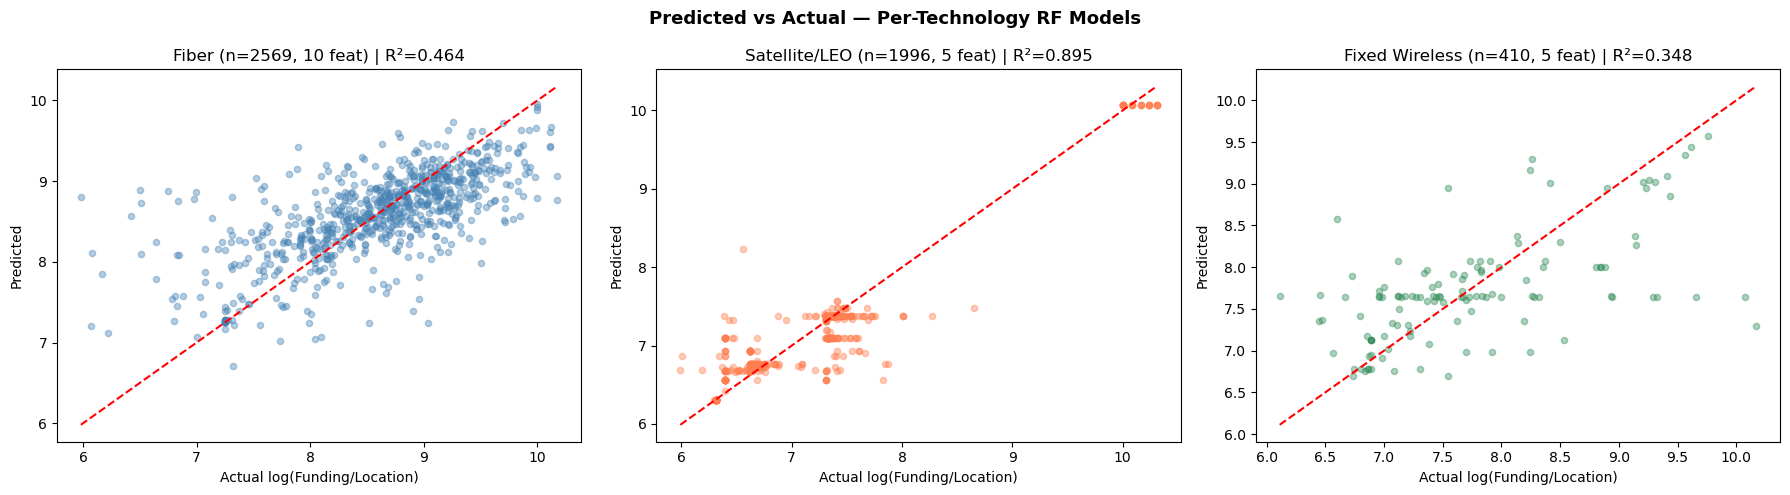

In [20]:
# ── Pred vs actual — per technology ───────────────────────────────────────────
fitted = [t for t in tech_order if t in models]
ncols  = min(len(fitted), 3)
nrows  = (len(fitted) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)

colors = {'Fiber': 'steelblue', 'Satellite/LEO': 'coral',
          'Fixed Wireless': 'seagreen', 'Cable/HFC': 'purple'}

for idx, tech in enumerate(fitted):
    r  = results[tech]
    ax = axes[idx // ncols][idx % ncols]
    ax.scatter(r['y_te'], r['y_pred'], alpha=0.4, s=20, color=colors.get(tech, 'grey'))
    lims = [min(r['y_te'].min(), r['y_pred'].min()), max(r['y_te'].max(), r['y_pred'].max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('Actual log(Funding/Location)')
    ax.set_ylabel('Predicted')
    n_feat = len(r['features'])
    ax.set_title(f'{tech} (n={r["n"]}, {n_feat} feat) | R²={r["r2_test"]:.3f}')

for idx in range(len(fitted), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.suptitle('Predicted vs Actual — Per-Technology RF Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_by_tech_pred_vs_actual.pdf', bbox_inches='tight')
plt.savefig('fig_by_tech_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

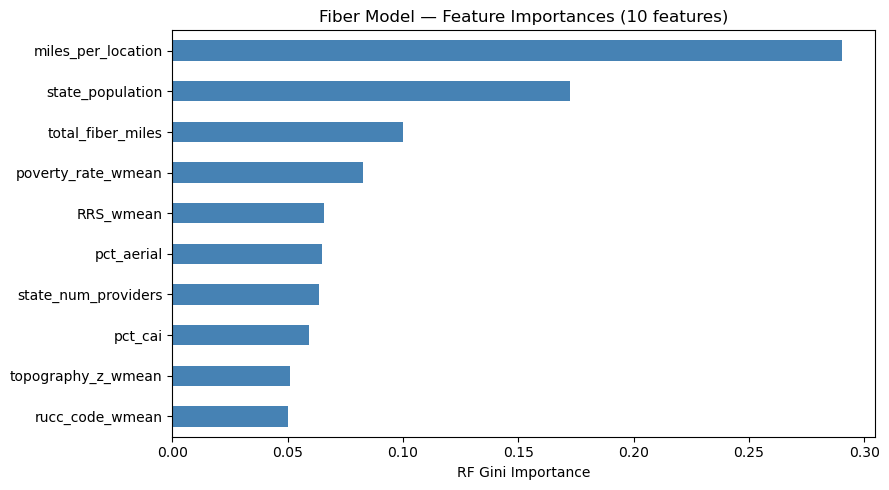

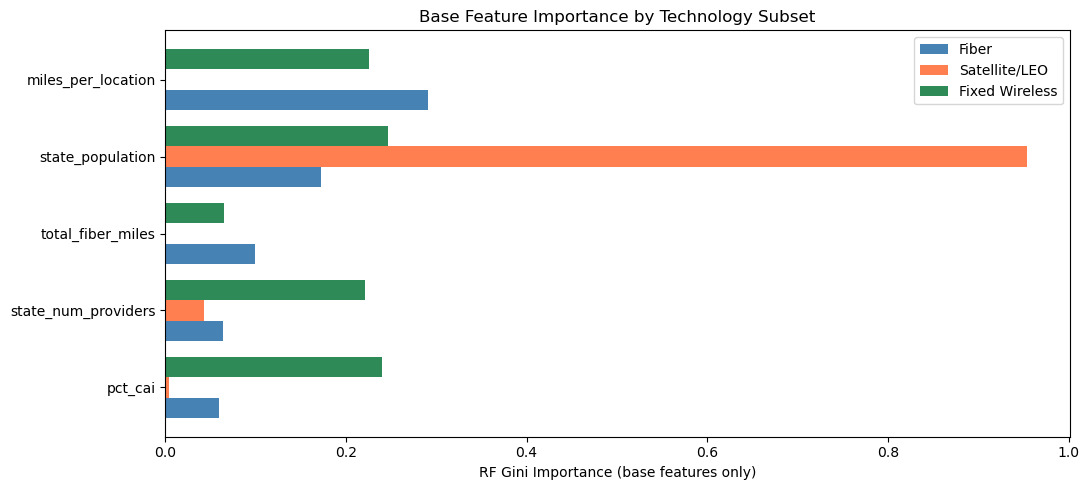

In [21]:
# ── Feature importance for fiber model (full feature set) ─────────────────────
if 'Fiber' in models:
    imp = results['Fiber']['importances'].sort_values()
    fig, ax = plt.subplots(figsize=(9, 5))
    imp.plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('RF Gini Importance')
    ax.set_title(f'Fiber Model — Feature Importances ({len(imp)} features)')
    plt.tight_layout()
    plt.savefig('fig_fiber_importance.pdf', bbox_inches='tight')
    plt.savefig('fig_fiber_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Feature importance for all fitted subsets (base features only for comparison)
base_imp = {}
for tech in fitted:
    imp_s = results[tech]['importances']
    base_imp[tech] = imp_s.reindex(BASE_FEATURES, fill_value=0)

imp_df = pd.DataFrame(base_imp).sort_values(fitted[0], ascending=True)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(BASE_FEATURES))
w = 0.8 / len(fitted)
offsets = np.linspace(-(len(fitted)-1)/2, (len(fitted)-1)/2, len(fitted)) * w
for i, tech in enumerate(fitted):
    ax.barh(x + offsets[i], imp_df[tech], w, label=tech, color=list(colors.values())[i])
ax.set_yticks(x)
ax.set_yticklabels(imp_df.index)
ax.set_xlabel('RF Gini Importance (base features only)')
ax.set_title('Base Feature Importance by Technology Subset')
ax.legend()
plt.tight_layout()
plt.savefig('fig_by_tech_importance.pdf', bbox_inches='tight')
plt.savefig('fig_by_tech_importance.png', dpi=150, bbox_inches='tight')
plt.show()

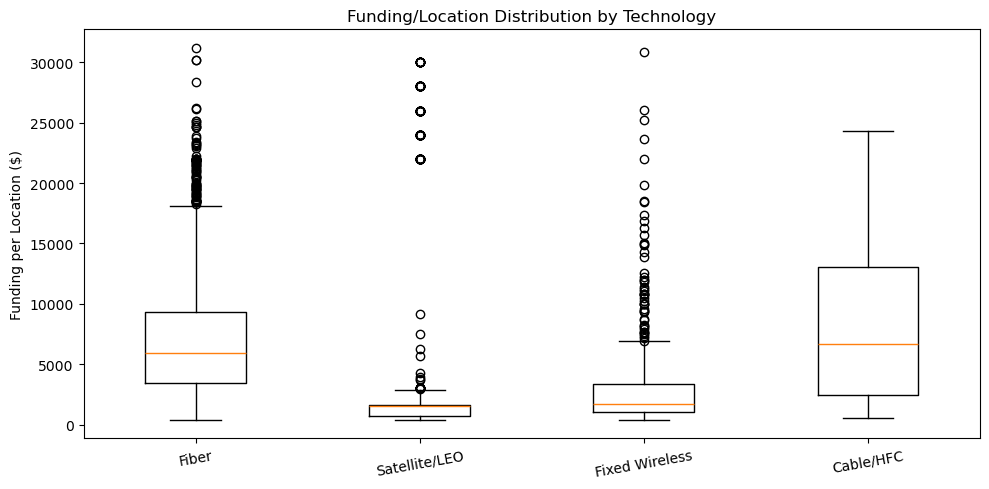

Median funding/location by technology:
  Fiber               : $     5,906  (n=2569)
  Satellite/LEO       : $     1,500  (n=1996)
  Fixed Wireless      : $     1,700  (n=410)
  Cable/HFC           : $     6,691  (n=43)


In [22]:
# ── Funding/location distributions by technology ───────────────────────────────
tech_present = [t for t in tech_order if t in df_pure['tech_group'].values]
data = [df_pure.loc[df_pure['tech_group'] == t, 'funding_per_location'].dropna() for t in tech_present]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=tech_present)
ax.set_ylabel('Funding per Location ($)')
ax.set_title('Funding/Location Distribution by Technology')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('fig_by_tech_funding_dist.pdf', bbox_inches='tight')
plt.savefig('fig_by_tech_funding_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median funding/location by technology:')
for t in tech_present:
    med = df_pure.loc[df_pure['tech_group'] == t, 'funding_per_location'].median()
    n   = (df_pure['tech_group'] == t).sum()
    print(f'  {t:20s}: ${med:>10,.0f}  (n={n})')

## Interpretation

**Why fiber has lower fit** than satellite/fixed-wireless:
- Fiber installation cost varies 10–100× with terrain, aerial vs buried split, soil type,
  labor markets, and existing conduit availability — none of which the base features capture.
- Satellite/LEO cost is mostly flat per location (equipment), so it's trivially predictable.

**New fiber features and expected contributions**:
- `pct_aerial`: largest expected contribution — aerial fiber costs ~$15–40k/mile vs
  buried $40–150k/mile.
- `topography_z_wmean` + `RRS_wmean`: terrain effects on buried cost.
- `rucc_code_wmean`: more rural = harder to reach = higher per-location cost.
- `poverty_rate_wmean`: correlates with geographic remoteness.

The ablation cell shows the incremental CV R² gain from each geographic feature,
confirming which ones actually move the needle for fiber.